# Edinburgh Airbnb Pricing Audit
### How Hosts Respond to Predictable Demand During the 2019 Festival Fringe

**Data:** InsideAirbnb Edinburgh (scraped June 25, 2019, via Kaggle)  
**Event:** Edinburgh Festival Fringe — August 2–26, 2019  
**Calendar Window:** June 25, 2019 → June 24, 2020

---

Every August, Edinburgh hosts the world's largest arts festival, generating a sharp and highly predictable increase in accommodation demand across the city.

This notebook examines how Airbnb hosts responded to that demand surge: who adjusted prices to capture the premium, and who left potential revenue unrealized.

The analysis proceeds in five stages:

1. Data cleaning and variable construction  
2. Market context — who lists, where, and at what price  
3. Signal verification — confirming the Fringe impacts pricing behavior  
4. The pricing gap — measuring which hosts adjust prices during peak demand  
5. Diagnostics — testing robustness, profiling excluded listings, and estimating market-wide revenue gaps

### Key Definitions

| Term | Definition |  Criteria / Calculation |
|---|---|---|
| **Price Index** | Listing day price relative to its normal pricing level | `day_price / baseline_median_price` |
| **Baseline Median Price** | Median listing price during lower-demand reference windows outside the Fringe period | — |
| **Flat-Pricer** | Listing whose median Fringe price remains close to baseline levels | `median_fringe_price_index < 1.1×` |
| **Host Tier** | Portfolio grouping based on total listings managed by a host | `1 listing`, `2–5 listings`, `6+ listings` |
| **Activity Tier** | Engagement grouping based on trailing 12-month review activity | Quantile split of `recent_review_count` |
| **Revenue Gap** | Difference between observed prices and prices implied by the market median Fringe markup | `potential_price − observed_price` |
| **Festival-Focused Listing** | Listing active primarily during the Fringe period with minimal baseline availability | `≥7 Fringe days` and `<3 baseline days` |

In [1]:
# ── 1. SETUP ──────────────────────────────────────────────────

from pathlib import Path

DATA_PATH = Path('./data')

import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})

TIER_COLORS = {
    'single_property': '#4C72B0',
    'small_portfolio': '#DD8452',
    'large_portfolio': '#55A868'
}

TIER_ORDER = [
    'single_property',
    'small_portfolio',
    'large_portfolio'
]

print('Setup complete')

Setup complete


In [2]:


# Load listings.csv
listings_raw = pd.read_csv(
    DATA_PATH / 'listings.csv',
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

# Load reviews.csv
reviews_raw = pd.read_csv(
    DATA_PATH / 'reviews.csv',
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

# Load calendar.csv
calendar_raw = pd.read_csv(
    DATA_PATH / 'calendar.csv',
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

# Quick shape check
print("Listings shape:", listings_raw.shape)
print("Reviews shape:", reviews_raw.shape)
print("Calendar shape:", calendar_raw.shape)

Listings shape: (13245, 106)
Reviews shape: (528631, 6)
Calendar shape: (4834568, 7)


---
## 1. Data Loading
Three files from InsideAirbnb: listings (property metadata), calendar (day-by-day price & availability, 365 days forward), and reviews (used to derive a booking-activity proxy).


---
## 1. Data Loading

The analysis uses three InsideAirbnb datasets:

- **Listings:** property and host metadata  
- **Calendar:** daily price and availability data for the following 365 days  
- **Reviews:** used to construct a booking activity proxy  

---

## 2. Data Cleaning & Variable Definitions

All variable definitions are established in this section and used consistently throughout the analysis.

### Host Tiers
Based on `calculated_host_listings_count`:

- `single_property`: 1 listing  
- `small_portfolio`: 2–5 listings  
- `large_portfolio`: 6+ listings  

### Activity Tiers
Based on trailing 12-month review counts as a proxy for booking activity:

- `low_activity`: ≤ Q25  
- `mid_activity`: Q25–Q75  
- `high_activity`: ≥ Q75  

### Price Index

`price_index = day_price / baseline_median_price`

Baseline price is defined as the median listing price across two lower-demand periods:

- Oct 1 – Nov 20, 2019  
- Jan 10 – Feb 20, 2020  

Listings require at least 10 valid baseline days to be included in indexed pricing analysis.

In [3]:
# ── 2.1 CLEAN LISTINGS ───────────────────────────────────────

key_cols = [
    'id',
    'host_id',
    'host_since',
    'host_response_rate',
    'host_is_superhost',
    'neighbourhood_cleansed',
    'latitude',
    'longitude',
    'property_type',
    'room_type',
    'accommodates',
    'price',
    'minimum_nights',
    'maximum_nights',
    'number_of_reviews',
    'last_review',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_value',
    'calculated_host_listings_count',
    'availability_365'
]

if 'number_of_reviews_ltm' in listings_raw.columns:
    key_cols.append('number_of_reviews_ltm')

key_cols = [col for col in key_cols if col in listings_raw.columns]

listings = listings_raw[key_cols].copy()

listings['price'] = (
    listings['price']
    .str.replace('[$£,]', '', regex=True)
    .astype(float)
)

listings['host_since'] = pd.to_datetime(
    listings['host_since'],
    errors='coerce'
)

listings['last_review'] = pd.to_datetime(
    listings['last_review'],
    errors='coerce'
)

if listings['host_response_rate'].dtype == object:
    listings['host_response_rate'] = (
        listings['host_response_rate']
        .str.replace('%', '')
        .astype(float)
    )

listings = listings[listings['price'].between(10, 1000)].copy()

listings['host_tier'] = listings['calculated_host_listings_count'].apply(
    lambda n: (
        'single_property'
        if n == 1
        else 'small_portfolio' if n <= 5 else 'large_portfolio'
    )
)

SCRAPE_DATE = pd.Timestamp('2019-06-25')

reviews_raw['date'] = pd.to_datetime(
    reviews_raw['date'],
    errors='coerce'
)

activity = (
    reviews_raw[
        (reviews_raw['date'] >= SCRAPE_DATE - pd.DateOffset(months=12)) &
        (reviews_raw['date'] <= SCRAPE_DATE)
    ]
    .groupby('listing_id')
    .size()
    .reset_index(name='recent_review_count')
)

listings = listings.merge(
    activity,
    left_on='id',
    right_on='listing_id',
    how='left'
)

listings['recent_review_count'] = (
    listings['recent_review_count']
    .fillna(0)
    .astype(int)
)

listings.drop(columns=['listing_id'], inplace=True)

q25 = listings['recent_review_count'].quantile(0.25)
q75 = listings['recent_review_count'].quantile(0.75)

listings['activity_tier'] = listings['recent_review_count'].apply(
    lambda n: (
        'low_activity'
        if n <= q25
        else 'high_activity' if n >= q75 else 'mid_activity'
    )
)

print(f'Listings after cleaning: {len(listings):,}')

for tier in TIER_ORDER:
    count = (listings['host_tier'] == tier).sum()
    pct = count / len(listings) * 100

    print(f'  {tier:20s}: {count:,} ({pct:.1f}%)')

Listings after cleaning: 13,191
  single_property     : 7,600 (57.6%)
  small_portfolio     : 3,857 (29.2%)
  large_portfolio     : 1,734 (13.1%)


In [4]:
# ── 2.2 CLEAN CALENDAR & BUILD PRICE INDEX ────────────────────

calendar = calendar_raw.copy()

calendar['date'] = pd.to_datetime(calendar['date'])
calendar['is_available'] = calendar['available'] == 't'

calendar['day_price'] = (
    calendar['price']
    .str.replace('[$£,]', '', regex=True)
    .astype(float)
)

calendar = calendar[
    calendar['listing_id'].isin(listings['id'])
].copy()

FRINGE_PEAK = ('2019-08-02', '2019-08-26')

BASELINE_WINDOWS = [
    ('2019-10-01', '2019-11-20'),
    ('2020-01-10', '2020-02-20')
]

def classify_date(date):
    if pd.Timestamp(FRINGE_PEAK[0]) <= date <= pd.Timestamp(FRINGE_PEAK[1]):
        return 'fringe'

    for start, end in BASELINE_WINDOWS:
        if pd.Timestamp(start) <= date <= pd.Timestamp(end):
            return 'baseline'

    return 'other'

calendar['window'] = calendar['date'].apply(classify_date)

baseline_stats = (
    calendar[
        (calendar['window'] == 'baseline') &
        calendar['is_available'] &
        calendar['day_price'].notna() &
        (calendar['day_price'] > 0)
    ]
    .groupby('listing_id')
    .agg(
        baseline_median_price=('day_price', 'median'),
        baseline_days=('day_price', 'count')
    )
    .reset_index()
)

baseline_stats = baseline_stats[
    baseline_stats['baseline_days'] >= 10
]

calendar = calendar.merge(
    baseline_stats[['listing_id', 'baseline_median_price']],
    on='listing_id',
    how='left'
)

calendar['price_index'] = (
    calendar['day_price'] /
    calendar['baseline_median_price']
)

merge_cols = [
    col for col in [
        'id',
        'host_id',
        'host_tier',
        'activity_tier',
        'recent_review_count',
        'neighbourhood_cleansed',
        'room_type',
        'price',
        'calculated_host_listings_count',
        'host_is_superhost',
        'host_response_rate',
        'host_since',
        'last_review',
        'review_scores_rating',
        'review_scores_value'
    ]
    if col in listings.columns
]

master = calendar.merge(
    listings[merge_cols],
    left_on='listing_id',
    right_on='id',
    how='inner'
)

master.rename(
    columns={'price_y': 'listing_base_price'},
    inplace=True
)

master.drop(columns=['id'], inplace=True)

print(
    f'Master calendar: {len(master):,} rows · '
    f'{master["listing_id"].nunique():,} listings'
)

print(f'Listings with valid price_index: {len(baseline_stats):,}')

Master calendar: 4,814,856 rows · 13,191 listings
Listings with valid price_index: 5,689


---
## 3. Market Context


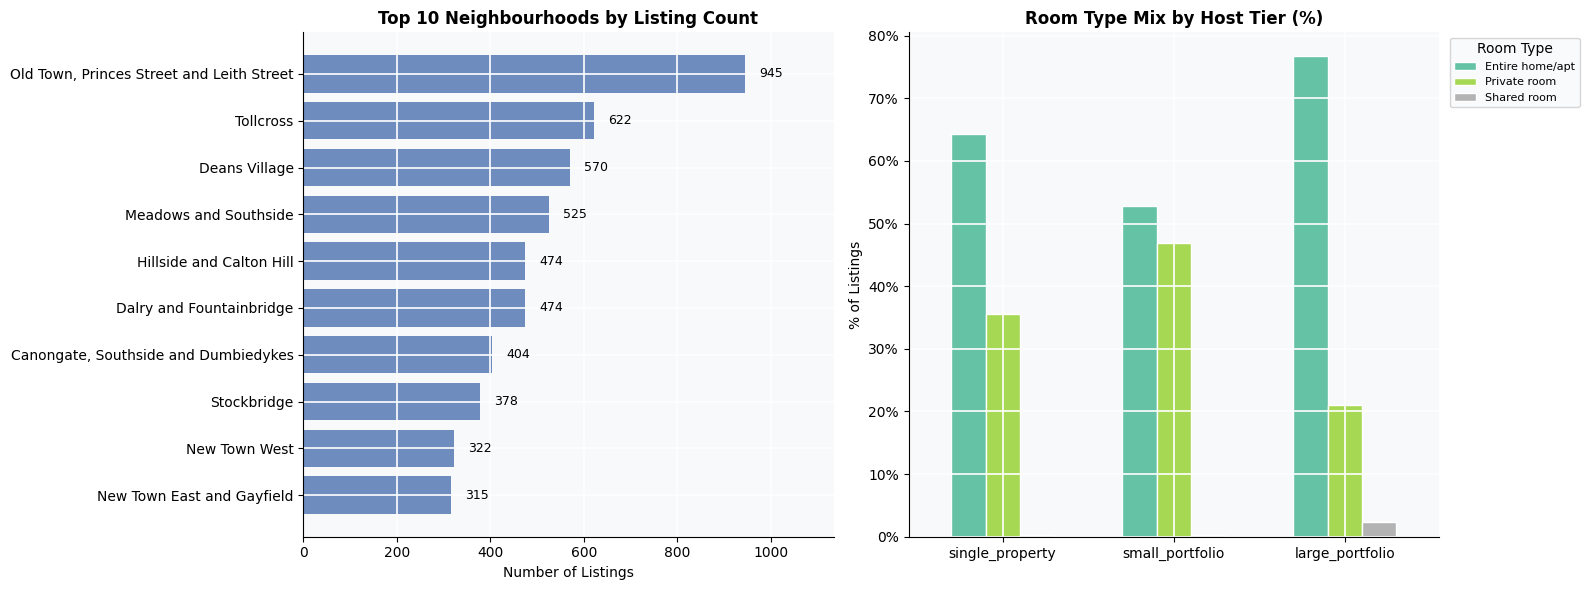

Total listings: 13,191 | Unique hosts: 9,316

Median base price by tier:
host_tier
single_property    70.00
small_portfolio    70.00
large_portfolio   102.00
Name: price, dtype: float64


In [5]:
# ── 3. MARKET SNAPSHOT ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]

top_neighborhoods = (
    listings['neighbourhood_cleansed']
    .value_counts()
    .head(10)
)

bars = ax.barh(
    top_neighborhoods.index[::-1],
    top_neighborhoods.values[::-1],
    color='#4C72B0',
    alpha=0.8
)

for bar, value in zip(bars, top_neighborhoods.values[::-1]):
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center',
        fontsize=9
    )

ax.set_title(
    'Top 10 Neighbourhoods by Listing Count',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('Number of Listings')
ax.set_xlim(0, top_neighborhoods.max() * 1.2)

ax2 = axes[1]

room_tier = (
    pd.crosstab(
        listings['host_tier'],
        listings['room_type'],
        normalize='index'
    ) * 100
).reindex(TIER_ORDER)

room_tier.plot(
    kind='bar',
    ax=ax2,
    colormap='Set2',
    width=0.6,
    edgecolor='white'
)

ax2.set_title(
    'Room Type Mix by Host Tier (%)',
    fontsize=12,
    fontweight='bold'
)

ax2.set_ylabel('% of Listings')
ax2.set_xlabel('')
ax2.set_xticklabels(TIER_ORDER, rotation=0)

ax2.legend(
    title='Room Type',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8
)

ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

print(
    f'Total listings: {len(listings):,} | '
    f'Unique hosts: {listings["host_id"].nunique():,}'
)

print('\nMedian base price by tier:')

print(
    listings.groupby('host_tier')['price']
    .median()
    .reindex(TIER_ORDER)
)

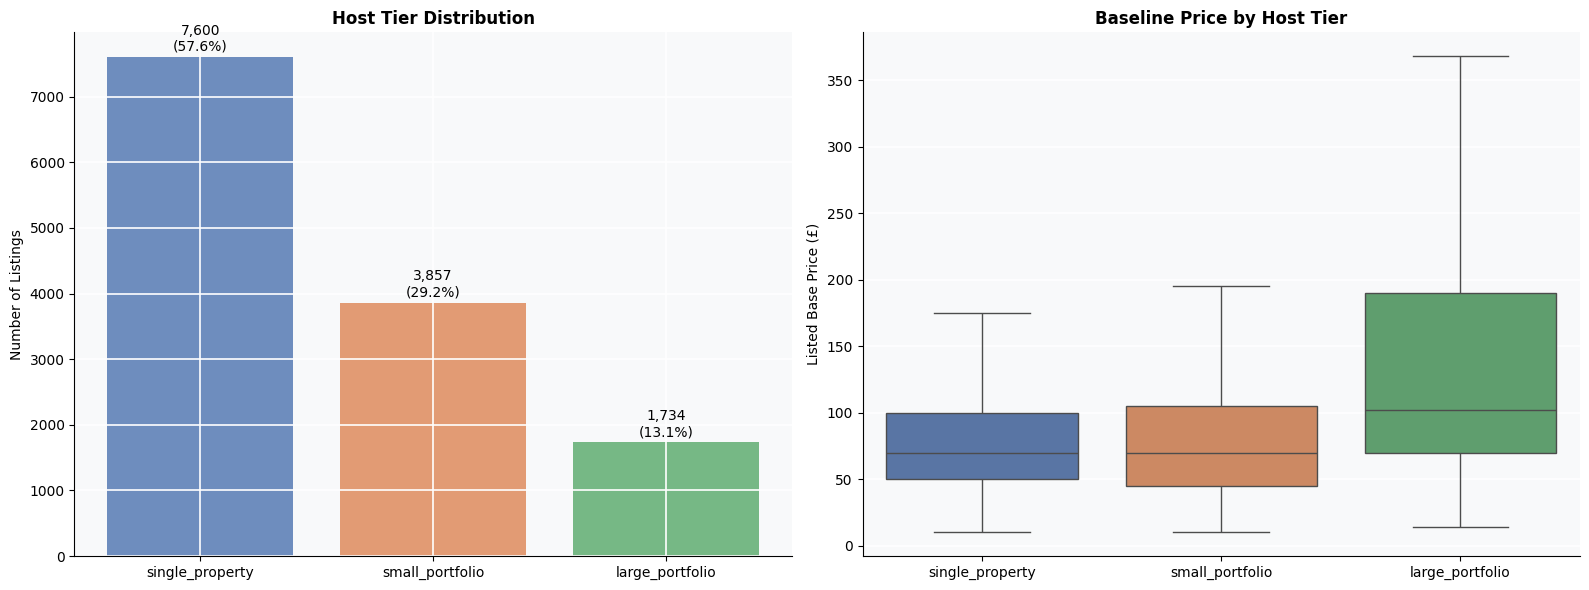

In [6]:
# ── 3.1 HOST COMPOSITION & BASE PRICING ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Host tier distribution
ax = axes[0]

tier_counts = (
    listings['host_tier']
    .value_counts()
    .reindex(TIER_ORDER)
)

bars = ax.bar(
    tier_counts.index,
    tier_counts.values,
    color=[TIER_COLORS[tier] for tier in TIER_ORDER],
    alpha=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f'{height:,}\n({height / len(listings) * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title(
    'Host Tier Distribution',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel('Number of Listings')

# Base price distribution by host tier
ax2 = axes[1]

sns.boxplot(
    data=listings,
    x='host_tier',
    y='price',
    order=TIER_ORDER,
    palette=TIER_COLORS,
    ax=ax2,
    showfliers=False
)

ax2.set_title(
    'Baseline Price by Host Tier',
    fontsize=12,
    fontweight='bold'
)

ax2.set_ylabel('Listed Base Price (£)')
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

In [7]:
fringe_prices = master[
    (master['window'] == 'fringe') &
    master['is_available'] &
    master['day_price'].notna() &
    (master['day_price'] > 0)
]

average_fringe_prices = (
    fringe_prices
    .groupby('host_tier')['day_price']
    .mean()
    .reindex(TIER_ORDER)
)

print('=== AVERAGE LISTING PRICE DURING THE FRINGE ===\n')

for tier, price in average_fringe_prices.items():
    print(f'{tier:20s}: £{price:,.2f}')

=== AVERAGE LISTING PRICE DURING THE FRINGE ===

single_property     : £157.06
small_portfolio     : £153.75
large_portfolio     : £266.26


---
## 4. The Fringe Signal

Before comparing different host groups, we first verify that the Edinburgh Fringe creates a measurable market-wide pricing response.

To do this, we track the weekly median `price_index` across the full calendar year. Because the price index normalizes each listing relative to its own baseline price, a rise above `1.0` indicates that listings are charging more than their typical off-season rates.

If the Fringe meaningfully impacts demand, we should observe a clear increase in market-wide pricing during the festival period.

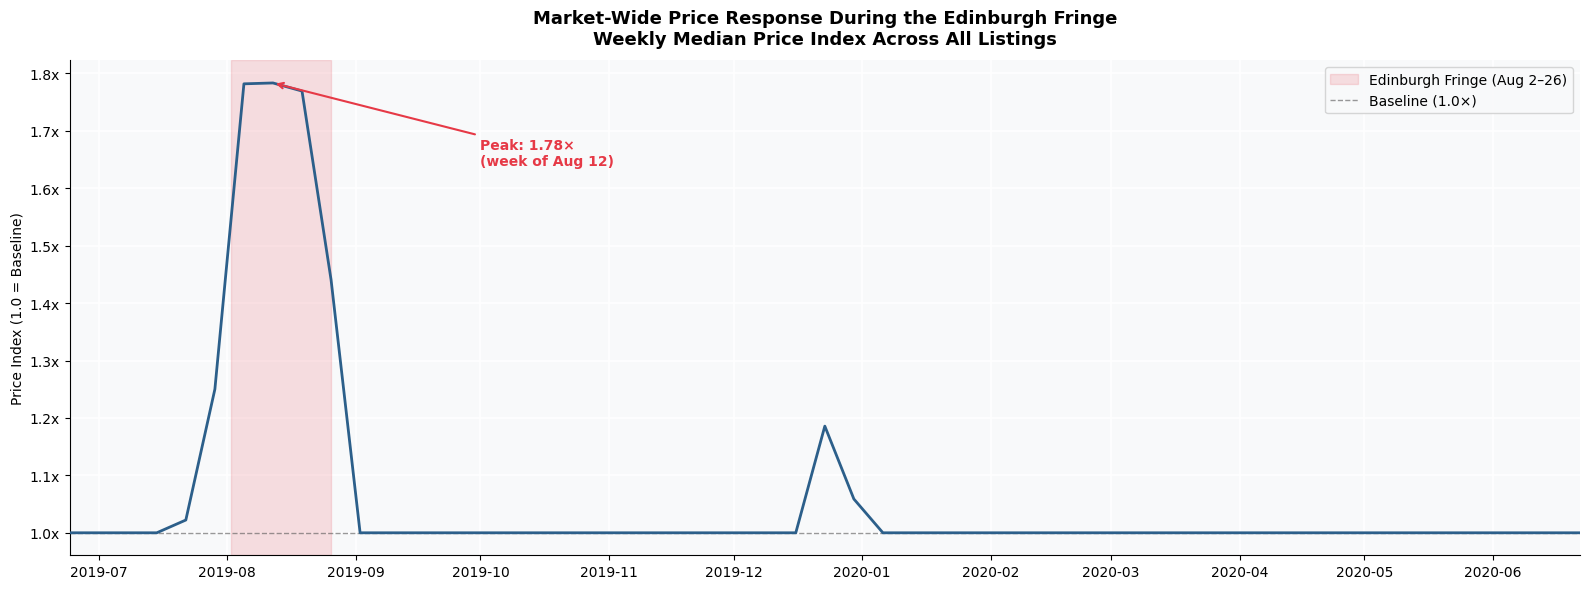

Peak Fringe-week median price index: 1.78×


In [8]:
# ── 4.1 MARKET-WIDE PRICE RESPONSE ────────────────────────────

weekly = (
    master[
        master['is_available'] &
        master['price_index'].notna() &
        (master['price_index'] > 0)
    ]
    .assign(
        week=lambda df: (
            df['date']
            .dt.to_period('W')
            .apply(lambda r: r.start_time)
        )
    )
    .groupby('week')
    .agg(median_price_index=('price_index', 'median'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    weekly['week'],
    weekly['median_price_index'],
    color='#2c5f8a',
    linewidth=2,
    zorder=3
)

ax.axvspan(
    pd.Timestamp('2019-08-02'),
    pd.Timestamp('2019-08-26'),
    alpha=0.15,
    color='#e63946',
    label='Edinburgh Fringe (Aug 2–26)',
    zorder=2
)

ax.axhline(
    1.0,
    color='#555',
    linewidth=1,
    linestyle='--',
    alpha=0.6,
    label='Baseline (1.0×)'
)

peak_week = weekly.loc[
    weekly['median_price_index'].idxmax()
]

ax.annotate(
    f'Peak: {peak_week["median_price_index"]:.2f}×\n'
    f'(week of {peak_week["week"].strftime("%b %d")})',
    xy=(peak_week['week'], peak_week['median_price_index']),
    xytext=(
        pd.Timestamp('2019-10-01'),
        peak_week['median_price_index'] * 0.92
    ),
    fontsize=10,
    fontweight='bold',
    color='#e63946',
    arrowprops=dict(
        arrowstyle='->',
        color='#e63946',
        lw=1.5
    )
)

ax.set_title(
    'Market-Wide Price Response During the Edinburgh Fringe\n'
    'Weekly Median Price Index Across All Listings',
    fontsize=13,
    fontweight='bold',
    pad=12
)

ax.set_ylabel('Price Index (1.0 = Baseline)')
ax.yaxis.set_major_formatter(
    mtick.FormatStrFormatter('%.1fx')
)

ax.set_xlim(
    weekly['week'].min(),
    weekly['week'].max()
)

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(
    f'Peak Fringe-week median price index: '
    f'{peak_week["median_price_index"]:.2f}×'
)

The Fringe creates a clear market-wide pricing response. During the festival period, the median listing reaches nearly **1.8× its baseline price**, showing that hosts across the city raise prices substantially in response to the demand surge.

Outside the Fringe window, prices remain relatively stable around baseline levels, suggesting the spike is strongly tied to the event itself.

The next step is to examine whether all host groups respond similarly — or whether some capture the premium more effectively than others.

---
## 5. The Pricing Gap

To measure how hosts respond to the Fringe demand surge, we define a **flat-pricer** as a listing with a median Fringe `price_index` below **1.1×** — meaning prices remained close to normal baseline levels despite peak demand conditions.

We first compare flat-pricing rates across host tiers, then test whether booking activity and engagement are more predictive of pricing behavior than portfolio size alone.

In [9]:
# ── 5.1 PREPARE FRINGE LISTING SUMMARIES ──────────────────────

fringe_peak_data = master[
    (master['window'] == 'fringe') &
    master['is_available'] &
    master['price_index'].notna()
].copy()

fringe_listings = (
    fringe_peak_data
    .groupby(
        ['listing_id', 'host_tier', 'activity_tier']
    )['price_index']
    .median()
    .reset_index()
)

fringe_listings['is_flat_pricer'] = (
    fringe_listings['price_index'] < 1.1
)

print(
    'Listings active during Fringe with valid '
    f'price_index: {len(fringe_listings):,}'
)

Listings active during Fringe with valid price_index: 4,742


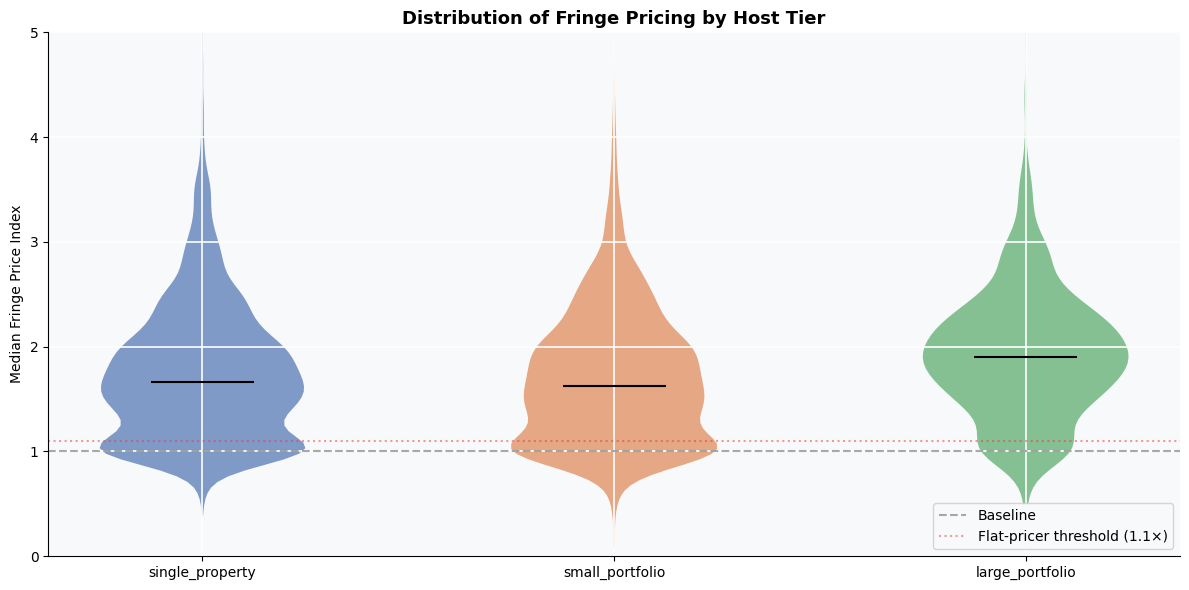

In [10]:
# ── 5.2 FRINGE PRICE INDEX DISTRIBUTIONS ──────────────────────

fig, ax = plt.subplots(figsize=(12, 6))

violin_data = [
    fringe_listings[
        fringe_listings['host_tier'] == tier
    ]['price_index'].values
    for tier in TIER_ORDER
]

parts = ax.violinplot(
    violin_data,
    positions=range(len(TIER_ORDER)),
    showmedians=True,
    showextrema=False
)

for i, body in enumerate(parts['bodies']):
    body.set_facecolor(list(TIER_COLORS.values())[i])
    body.set_alpha(0.7)

parts['cmedians'].set_color('black')

ax.set_xticks(range(len(TIER_ORDER)))
ax.set_xticklabels(TIER_ORDER)

ax.axhline(
    1.0,
    color='#555',
    linestyle='--',
    alpha=0.5,
    label='Baseline'
)

ax.axhline(
    1.1,
    color='#e63946',
    linestyle=':',
    alpha=0.5,
    label='Flat-pricer threshold (1.1×)'
)

ax.set_ylabel('Median Fringe Price Index')
ax.set_ylim(0, 5)

ax.set_title(
    'Distribution of Fringe Pricing by Host Tier',
    fontsize=13,
    fontweight='bold'
)

ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# ── 5.3 FLAT-PRICER RATES & STATISTICAL TEST ──────────────────

print('=== FLAT-PRICER RATE BY HOST TIER ===\n')

flat_by_tier = (
    fringe_listings
    .groupby('host_tier')['is_flat_pricer']
    .agg(['count', 'mean'])
)

flat_by_tier['pct_flat'] = (
    flat_by_tier['mean'] * 100
).round(1)

print(
    flat_by_tier[['count', 'pct_flat']]
    .reindex(TIER_ORDER)
)

single_property = fringe_listings[
    fringe_listings['host_tier'] == 'single_property'
]['price_index']

large_portfolio = fringe_listings[
    fringe_listings['host_tier'] == 'large_portfolio'
]['price_index']

stat, pval = mannwhitneyu(
    large_portfolio,
    single_property,
    alternative='greater'
)

print(
    '\nMann–Whitney U '
    '(large_portfolio vs single_property): '
    f'U={stat:,.0f}, p={pval:.4e}'
)

=== FLAT-PRICER RATE BY HOST TIER ===

                 count  pct_flat
host_tier                       
single_property   2429     20.10
small_portfolio   1473     22.50
large_portfolio    840     10.20

Mann–Whitney U (large_portfolio vs single_property): U=1,212,463, p=1.6301e-16


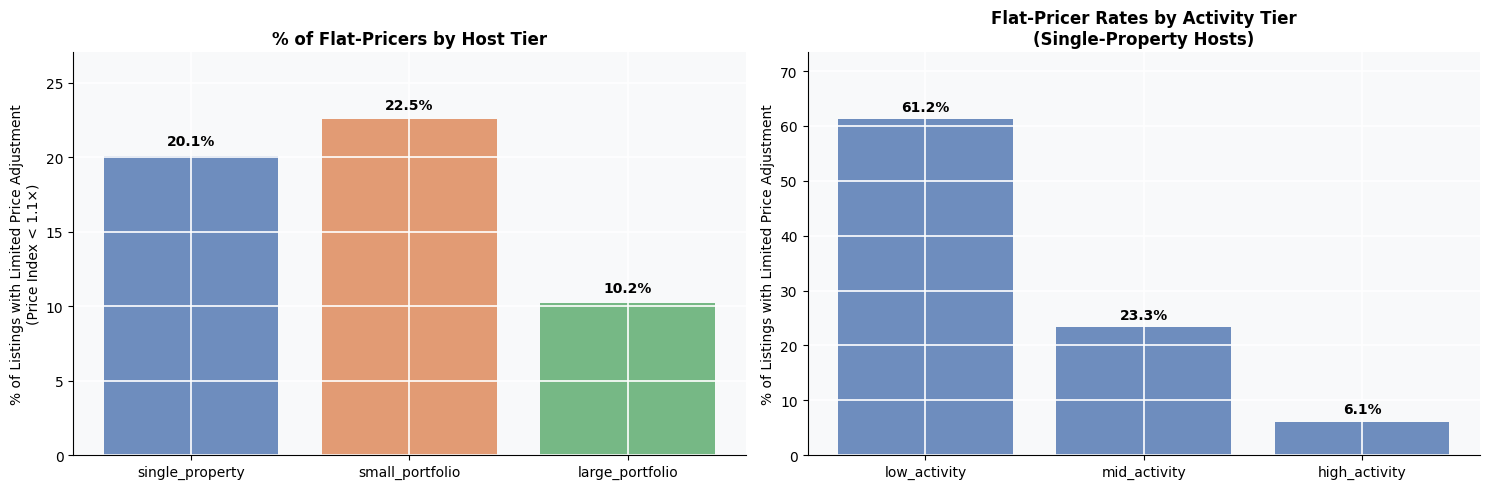

In [12]:
# ── 5.4 FLAT-PRICER RATES BY HOST & ACTIVITY TIER ─────────────

flat_by_tier = (
    fringe_listings
    .groupby('host_tier')['is_flat_pricer']
    .mean()
    .mul(100)
    .reindex(TIER_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Flat-pricer rate by host tier
ax1 = axes[0]

bars1 = ax1.bar(
    flat_by_tier.index,
    flat_by_tier.values,
    color=[TIER_COLORS[tier] for tier in TIER_ORDER],
    alpha=0.8
)

for bar in bars1:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax1.set_title(
    '% of Flat-Pricers by Host Tier',
    fontsize=12,
    fontweight='bold'
)

ax1.set_ylabel(
    '% of Listings with Limited Price Adjustment\n'
    '(Price Index < 1.1×)'
)

ax1.set_ylim(0, flat_by_tier.max() * 1.2)

# Flat-pricer rate by activity tier (single-property hosts only)
ax2 = axes[1]

single_property_hosts = fringe_listings[
    fringe_listings['host_tier'] == 'single_property'
]

activity_flat = (
    single_property_hosts
    .groupby('activity_tier')['is_flat_pricer']
    .mean()
    .mul(100)
    .reindex([
        'low_activity',
        'mid_activity',
        'high_activity'
    ])
)

bars2 = ax2.bar(
    activity_flat.index,
    activity_flat.values,
    color='#4C72B0',
    alpha=0.8
)

for bar in bars2:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax2.set_title(
    'Flat-Pricer Rates by Activity Tier\n'
    '(Single-Property Hosts)',
    fontsize=12,
    fontweight='bold'
)

ax2.set_ylabel('% of Listings with Limited Price Adjustment')
ax2.set_ylim(0, activity_flat.max() * 1.2)

plt.tight_layout()
plt.show()

---
## 5.5 Investigating Small-Portfolio Hosts

One result stands out throughout the analysis: hosts managing **2–5 listings** consistently show weaker pricing responses than both single-property hosts and large portfolio operators.

This section examines whether that pattern can be explained by differences in property mix, pricing behavior, or operational responsiveness during the Fringe period.

In [13]:
# ── 5.5.1 ROOM TYPE MIX BY HOST TIER ──────────────────────────

print('=== ROOM TYPE DISTRIBUTION BY HOST TIER (%) ===\n')

room_distribution = (
    pd.crosstab(
        listings['host_tier'],
        listings['room_type'],
        normalize='index'
    )
    .mul(100)
    .reindex(TIER_ORDER)
    .round(1)
)

print(room_distribution)

print('\n=== MEDIAN FRINGE PRICE INDEX BY HOST TIER × ROOM TYPE ===\n')

fringe_with_room = fringe_listings.copy()

fringe_with_room['room_type'] = fringe_with_room['listing_id'].map(
    listings.set_index('id')['room_type']
)

room_type_pricing = (
    fringe_with_room
    .groupby(['host_tier', 'room_type'])['price_index']
    .median()
    .unstack()
    .reindex(TIER_ORDER)
    .round(2)
)

print(room_type_pricing)

=== ROOM TYPE DISTRIBUTION BY HOST TIER (%) ===

room_type        Entire home/apt  Private room  Shared room
host_tier                                                  
single_property            64.20         35.50         0.20
small_portfolio            52.80         46.90         0.30
large_portfolio            76.70         21.00         2.30

=== MEDIAN FRINGE PRICE INDEX BY HOST TIER × ROOM TYPE ===

room_type        Entire home/apt  Private room  Shared room
host_tier                                                  
single_property             1.80          1.33         1.11
small_portfolio             1.84          1.33         1.93
large_portfolio             1.90          1.82         2.40


Small-portfolio hosts manage a higher share of private rooms than other host groups, which partly contributes to lower overall pricing levels during the Fringe.

However, even within the same room type categories, their pricing response remains weaker than large portfolio operators. For example, large portfolios achieve higher median price indices for both entire homes and private rooms during the festival period.

This suggests that property mix alone does not fully explain the pricing gap.

In [14]:
# ── 5.5.2 WEEKDAY VS WEEKEND PRICING RESPONSE ─────────────────

weekend_pricing = (
    fringe_peak_data[fringe_peak_data['price_index'].notna()]
    .groupby([
        'host_tier',
        fringe_peak_data['date']
        .dt.dayofweek
        .isin([5, 6])
        .rename('is_weekend')
    ])['price_index']
    .median()
    .unstack()
    .reindex(TIER_ORDER)
)

weekend_pricing.columns = ['Weekday', 'Weekend']

print('=== MEDIAN FRINGE PRICE INDEX: WEEKDAY VS WEEKEND ===\n')

print(weekend_pricing.round(2))

=== MEDIAN FRINGE PRICE INDEX: WEEKDAY VS WEEKEND ===

                 Weekday  Weekend
host_tier                        
single_property     1.74     1.79
small_portfolio     1.62     1.64
large_portfolio     1.94     2.00


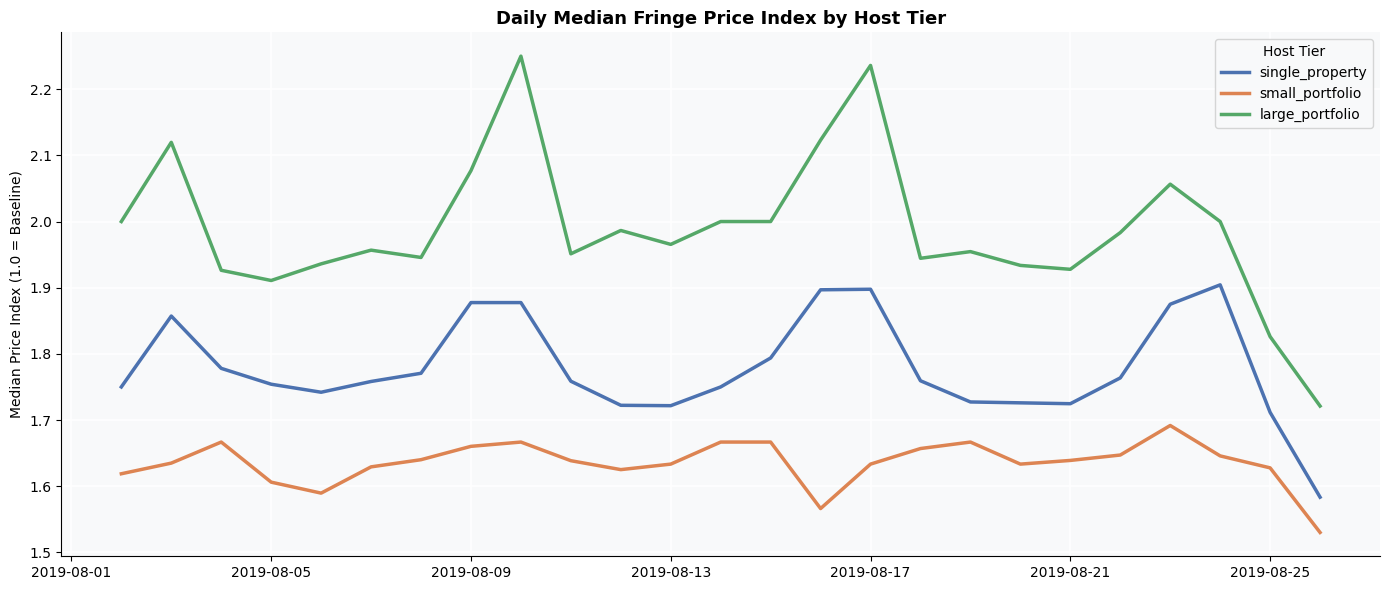

In [15]:
# ── 5.5.3 DAILY PRICE INDEX DURING THE FRINGE ─────────────────

daily_fringe = (
    fringe_peak_data[fringe_peak_data['price_index'].notna()]
    .groupby(['date', 'host_tier'])['price_index']
    .median()
    .unstack()
    .reindex(columns=TIER_ORDER)
)

fig, ax = plt.subplots(figsize=(14, 6))

for tier in TIER_ORDER:
    ax.plot(
        daily_fringe.index,
        daily_fringe[tier],
        label=tier,
        color=TIER_COLORS[tier],
        linewidth=2.5
    )

ax.set_title(
    'Daily Median Fringe Price Index by Host Tier',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel('Median Price Index (1.0 = Baseline)')
ax.legend(title='Host Tier')

plt.tight_layout()
plt.show()

In [16]:
# ── 5.5.4 PRICE UPDATE ACTIVITY DURING THE FRINGE ─────────────

price_changes = (
    fringe_peak_data
    .sort_values(['listing_id', 'date'])
    .groupby(['listing_id', 'host_tier'])['day_price']
    .apply(lambda x: (x.diff().fillna(0) != 0).sum())
    .reset_index()
    .rename(columns={'day_price': 'n_price_changes'})
)

thresholds = [1, 3, 5]

print('=== % OF LISTINGS CHANGING PRICE AT LEAST N TIMES ===\n')

print(f"{'Threshold':<15} {'Single':>12} {'Small':>12} {'Large':>12}")
print('-' * 55)

for threshold in thresholds:

    row = (
        price_changes
        .groupby('host_tier')
        .apply(
            lambda x: (
                x['n_price_changes'] >= threshold
            ).mean() * 100
        )
        .reindex(TIER_ORDER)
    )

    print(
        f">= {threshold} changes"
        f"{row['single_property']:>12.1f}%"
        f"{row['small_portfolio']:>12.1f}%"
        f"{row['large_portfolio']:>12.1f}%"
    )

=== % OF LISTINGS CHANGING PRICE AT LEAST N TIMES ===

Threshold             Single        Small        Large
-------------------------------------------------------
>= 1 changes        44.9%        42.3%        53.3%
>= 3 changes        24.8%        21.5%        27.9%
>= 5 changes        17.4%        13.5%        19.0%


The investigation points to two main factors behind the weak pricing response of small-portfolio hosts:

- **Property mix:**  
  Small-portfolio hosts manage a higher share of private rooms, which generally experience smaller Fringe price increases than entire homes.

- **Pricing behavior:**  
  Even within the same room types, large portfolio operators achieve higher price indices. Small-portfolio hosts also show weaker weekday-to-weekend variation and are less likely to update prices repeatedly during the Fringe.

Together, these patterns suggest that small-portfolio hosts combine a less favorable listing mix with less dynamic pricing behavior, resulting in the highest concentration of flat-pricers in the market.

---
## 6. Pricing Timing & Market Response

So far, the analysis has focused on how strongly different host groups respond to Fringe demand. This section looks at timing: when do hosts begin adjusting prices ahead of the festival?

The calendar data was scraped on June 25, 2019, more than a month before the Fringe began on August 2. Listings that already showed elevated August prices at the time of the scrape can therefore be interpreted as responding proactively to expected demand.

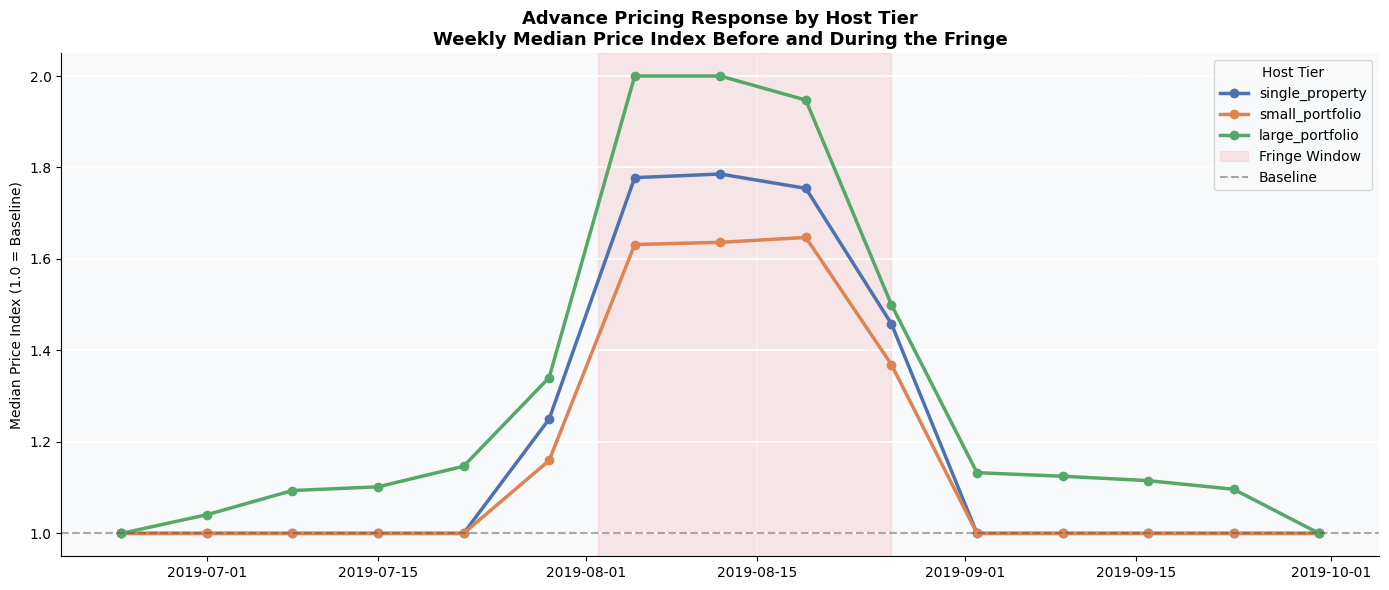

In [17]:
# ── 6.1 PRICE ADJUSTMENTS LEADING INTO THE FRINGE ─────────────

timing_data = master[
    master['is_available'] &
    master['price_index'].notna() &
    (master['date'] >= '2019-06-25') &
    (master['date'] <= '2019-09-30')
].copy()

timing_curve = (
    timing_data
    .assign(
        week=lambda df: (
            df['date']
            .dt.to_period('W')
            .apply(lambda r: r.start_time)
        )
    )
    .groupby(['week', 'host_tier'])['price_index']
    .median()
    .unstack()
)

fig, ax = plt.subplots(figsize=(14, 6))

for tier in TIER_ORDER:
    ax.plot(
        timing_curve.index,
        timing_curve[tier],
        label=tier,
        color=TIER_COLORS[tier],
        linewidth=2.5,
        marker='o'
    )

ax.axvspan(
    pd.Timestamp('2019-08-02'),
    pd.Timestamp('2019-08-26'),
    alpha=0.1,
    color='#e63946',
    label='Fringe Window'
)

ax.axhline(
    1.0,
    color='#555',
    linestyle='--',
    alpha=0.5,
    label='Baseline'
)

ax.set_title(
    'Advance Pricing Response by Host Tier\n'
    'Weekly Median Price Index Before and During the Fringe',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel('Median Price Index (1.0 = Baseline)')
ax.legend(title='Host Tier')

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Diagnostics & Robustness

The pricing gap is clear, but the results should still be tested for robustness.

This section evaluates whether the observed patterns depend on specific grouping choices or sample construction. We begin with a sensitivity analysis of portfolio size definitions by examining flat-pricing rates across exact host listing counts, rather than the broader tier categories used earlier in the notebook.

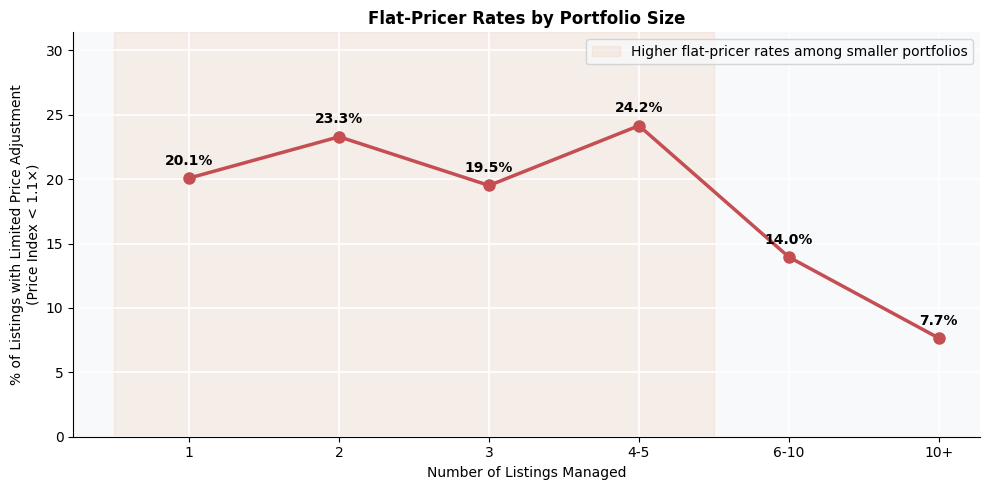

In [18]:
# ── 7.1 SENSITIVITY ANALYSIS: PORTFOLIO SIZE ──────────────────

def get_fine_tier(n):
    if n == 1:
        return '1'
    if n == 2:
        return '2'
    if n == 3:
        return '3'
    if n <= 5:
        return '4-5'
    if n <= 10:
        return '6-10'
    return '10+'

fringe_listings['fine_tier'] = (
    fringe_listings['listing_id']
    .map(
        listings.set_index('id')[
            'calculated_host_listings_count'
        ]
    )
    .apply(get_fine_tier)
)

fine_tier_order = [
    '1',
    '2',
    '3',
    '4-5',
    '6-10',
    '10+'
]

sensitivity = (
    fringe_listings
    .groupby('fine_tier')['is_flat_pricer']
    .mean()
    .mul(100)
    .reindex(fine_tier_order)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    sensitivity.index,
    sensitivity.values,
    marker='o',
    color='#c44e52',
    linewidth=2.5,
    markersize=8
)

for i, value in enumerate(sensitivity.values):
    ax.text(
        i,
        value + 0.8,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax.axvspan(
    -0.5,
    3.5,
    color='#DD8452',
    alpha=0.1,
    label='Higher flat-pricer rates among smaller portfolios'
)

ax.set_title(
    'Flat-Pricer Rates by Portfolio Size',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    '% of Listings with Limited Price Adjustment\n'
    '(Price Index < 1.1×)'
)

ax.set_xlabel('Number of Listings Managed')

ax.set_ylim(0, sensitivity.max() * 1.3)

ax.legend()

plt.tight_layout()
plt.show()

### Interpreting the Portfolio Size Pattern

The sensitivity analysis shows that pricing efficiency does not improve steadily with portfolio size. Hosts managing 2–5 listings exhibit the highest flat-pricing rates, while larger portfolio operators respond more aggressively to Fringe demand.

This suggests that the weaker pricing response among small-portfolio hosts is not driven by a single threshold choice, but reflects a broader behavioral pattern across intermediate portfolio sizes.

Next, we run a controlled comparison to test whether the observed gap is driven by location or property type composition.

To do this, we restrict the sample to:
- **Entire homes only**
- Listings located in the **suburbs**

This removes both the pricing dynamics of private rooms and the location advantage of central Fringe areas.

In [19]:
# ── 7.2 CONTROLLED TEST: LOCATION & PROPERTY TYPE ─────────────

fringe_core_neighborhoods = [
    'Old Town, Princes Street and Leith Street',
    'Tollcross',
    'Deans Village',
    'Southside',
    'New Town'
]

fringe_listings['location_type'] = (
    fringe_listings['listing_id']
    .map(
        listings.set_index('id')[
            'neighbourhood_cleansed'
        ]
    )
    .apply(
        lambda x: (
            'Core'
            if x in fringe_core_neighborhoods
            else 'Suburbs'
        )
    )
)

fringe_listings['room_type'] = (
    fringe_listings['listing_id']
    .map(
        listings.set_index('id')['room_type']
    )
)

print('=== FLAT-PRICER RATE BY LOCATION ===\n')

geo_test = (
    fringe_listings
    .groupby(['host_tier', 'location_type'])['is_flat_pricer']
    .mean()
    .unstack()
    .mul(100)
    .round(1)
    .reindex(TIER_ORDER)
)

print(geo_test)

controlled_subset = fringe_listings[
    (fringe_listings['location_type'] == 'Suburbs') &
    (fringe_listings['room_type'] == 'Entire home/apt')
]

controlled_flat = (
    controlled_subset
    .groupby('host_tier')['is_flat_pricer']
    .agg(['count', 'mean'])
)

controlled_flat['pct_flat'] = (
    controlled_flat['mean'] * 100
).round(1)

print('\n=== ENTIRE HOMES IN SUBURBAN AREAS ===\n')

print(
    f'Controlled subset size: '
    f'{len(controlled_subset):,} listings\n'
)

print(
    controlled_flat[['count', 'pct_flat']]
    .reindex(TIER_ORDER)
)

=== FLAT-PRICER RATE BY LOCATION ===

location_type    Core  Suburbs
host_tier                     
single_property  8.70    22.30
small_portfolio 10.50    25.90
large_portfolio  9.90    10.50

=== ENTIRE HOMES IN SUBURBAN AREAS ===

Controlled subset size: 2,472 listings

                 count  pct_flat
host_tier                       
single_property   1454     16.00
small_portfolio    646     17.20
large_portfolio    372      9.40


Even after controlling for both geography and property type, the gap persists:

- **single_property:** ~16% flat-pricers  
- **small_portfolio:** ~17% flat-pricers  
- **large_portfolio:** ~9% flat-pricers  

This suggests that the earlier results are not driven solely by location or room-type composition.

---

## 8. The Excluded Segment & Revenue Gap

The indexed pricing analysis required listings to have at least 10 valid baseline days. As a result, roughly **39% of Fringe-active listings** were excluded from the main sample because they lacked sufficient baseline availability.

Many of these listings appear to operate primarily during the festival period itself. Since they have little or no off-season activity, they cannot be evaluated using the same baseline-normalized pricing framework.

In [20]:
# ── 8.1 PROFILING THE EXCLUDED SEGMENT ────────────────────────

all_fringe_active = calendar[
    (calendar['window'] == 'fringe') &
    calendar['is_available']
]['listing_id'].unique()

included_listings = baseline_stats['listing_id'].unique()

excluded_listings = (
    set(all_fringe_active) -
    set(included_listings)
)

print(f'Total active Fringe listings: {len(all_fringe_active):,}')

print(
    f'Excluded listings (no valid baseline): '
    f'{len(excluded_listings):,} '
    f'({len(excluded_listings) / len(all_fringe_active) * 100:.1f}%)\n'
)

excluded_cal = calendar[
    calendar['listing_id'].isin(excluded_listings)
]

avail_by_window = (
    excluded_cal[excluded_cal['is_available']]
    .groupby('listing_id')['window']
    .value_counts()
    .unstack(fill_value=0)
)

festival_focused = avail_by_window[
    (avail_by_window.get('fringe', 0) >= 7) &
    (avail_by_window.get('baseline', 0) < 3)
].index

print(
    'Festival-focused listings '
    '(≥7 Fringe days, <3 baseline days): '
    f'{len(festival_focused):,}'
)

print(
    f'This represents '
    f'{len(festival_focused) / len(excluded_listings) * 100:.1f}% '
    'of the excluded segment.'
)

Total active Fringe listings: 7,805
Excluded listings (no valid baseline): 3,063 (39.2%)

Festival-focused listings (≥7 Fringe days, <3 baseline days): 1,882
This represents 61.4% of the excluded segment.


The excluded segment is not random.

Of the 3,063 Fringe-active listings excluded from the indexed analysis, over 60% appear to operate primarily during the festival period itself, with little or no baseline availability outside the Fringe window.

These festival-focused listings are important because they represent a large share of market activity, yet cannot be evaluated using the same baseline-normalized pricing framework applied to the main sample.

## 8.2 Diagnostic: Are Excluded Listings Simply Newer?

One possible explanation for the excluded segment is that these listings joined Airbnb recently and therefore lack sufficient baseline availability.

If excluded listings are systematically newer than the main sample, their exclusion may reflect limited historical data rather than different hosting behavior.

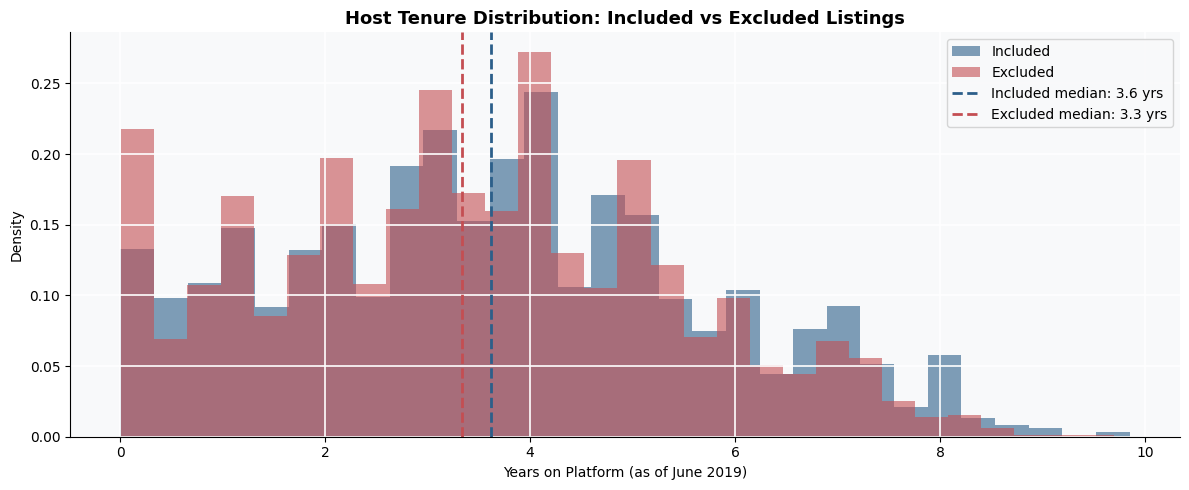

In [21]:
# ── 8.2 HOST TENURE: INCLUDED VS EXCLUDED LISTINGS ────────────

listings['host_since_dt'] = pd.to_datetime(
    listings['host_since'],
    errors='coerce'
)

scrape_date = pd.Timestamp('2019-06-25')

listings['tenure_years'] = (
    scrape_date - listings['host_since_dt']
).dt.days / 365

listings['analysis_group'] = listings['id'].apply(
    lambda x: (
        'Included'
        if x in included_listings
        else (
            'Excluded'
            if x in excluded_listings
            else 'Other'
        )
    )
)

inc_tenure = listings[
    listings['analysis_group'] == 'Included'
]['tenure_years'].dropna()

exc_tenure = listings[
    listings['analysis_group'] == 'Excluded'
]['tenure_years'].dropna()

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    inc_tenure.clip(0, 10),
    bins=30,
    alpha=0.6,
    color='#2c5f8a',
    label='Included',
    density=True
)

ax.hist(
    exc_tenure.clip(0, 10),
    bins=30,
    alpha=0.6,
    color='#C44E52',
    label='Excluded',
    density=True
)

ax.axvline(
    inc_tenure.median(),
    color='#2c5f8a',
    linestyle='--',
    linewidth=2,
    label=f'Included median: {inc_tenure.median():.1f} yrs'
)

ax.axvline(
    exc_tenure.median(),
    color='#C44E52',
    linestyle='--',
    linewidth=2,
    label=f'Excluded median: {exc_tenure.median():.1f} yrs'
)

ax.set_title(
    'Host Tenure Distribution: Included vs Excluded Listings',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Years on Platform (as of June 2019)')
ax.set_ylabel('Density')

ax.legend()

plt.tight_layout()
plt.show()

**Result:** The tenure distributions are broadly similar. Excluded listings do not appear to be systematically newer than the main analysis sample.

## 8.3 Diagnostic: Are Excluded Listings Lower Quality?

Another possibility is that excluded listings are structurally lower quality and therefore less capable of capturing Fringe pricing premiums.

To test this, we compare observable quality indicators between included and excluded listings.

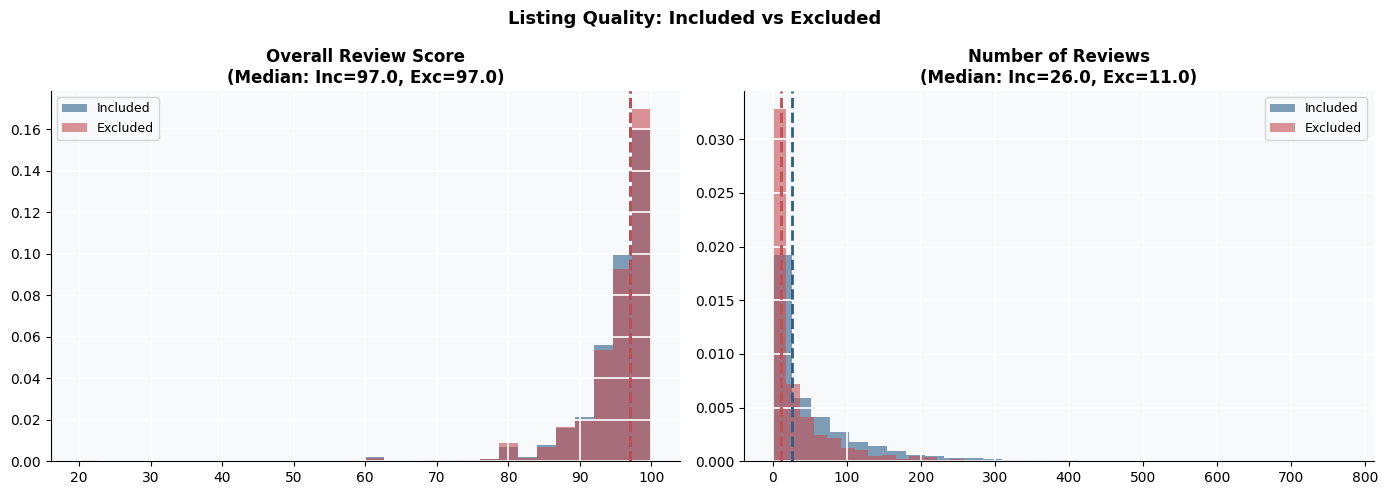

In [22]:
# ── 8.3 LISTING QUALITY: INCLUDED VS EXCLUDED ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = [
    ('review_scores_rating', 'Overall Review Score'),
    ('number_of_reviews', 'Number of Reviews')
]

for ax, (column, title) in zip(axes, metrics):

    if column not in listings.columns:
        continue

    inc_vals = listings[
        listings['analysis_group'] == 'Included'
    ][column].dropna()

    exc_vals = listings[
        listings['analysis_group'] == 'Excluded'
    ][column].dropna()

    ax.hist(
        inc_vals,
        bins=30,
        alpha=0.6,
        color='#2c5f8a',
        label='Included',
        density=True
    )

    ax.hist(
        exc_vals,
        bins=30,
        alpha=0.6,
        color='#C44E52',
        label='Excluded',
        density=True
    )

    ax.axvline(
        inc_vals.median(),
        color='#2c5f8a',
        linestyle='--',
        linewidth=2
    )

    ax.axvline(
        exc_vals.median(),
        color='#C44E52',
        linestyle='--',
        linewidth=2
    )

    ax.set_title(
        f'{title}\n'
        f'(Median: Inc={inc_vals.median():.1f}, '
        f'Exc={exc_vals.median():.1f})',
        fontweight='bold'
    )

    ax.legend(fontsize=9)

plt.suptitle(
    'Listing Quality: Included vs Excluded',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Result:** Review scores are nearly identical between the two groups. Excluded listings mainly differ in review volume, which is consistent with lower year-round activity rather than lower observable quality.

## 8.4 Estimating the Revenue Gap

To keep the revenue-gap estimate conservative, we apply an additional filter to the excluded segment. We define a festival-focused listing as one with:

- **≥7 available Fringe days**
- **<3 available baseline days**

This isolates listings that appear to operate primarily during the festival period while excluding highly inactive or irregular listings.

The filtered group contains 1,882 festival-focused listings. The remaining excluded listings are omitted from the revenue-gap calculation entirely.

We estimate the revenue gap by comparing observed prices with prices implied by the market-wide median Fringe markup (1.77×). For festival-focused listings, we additionally apply a 50% occupancy discount to avoid overstating unrealized revenue.

In [23]:
# ── 8.4 ESTIMATED REVENUE GAP ─────────────────────────────────

MARKET_MEDIAN_MARKUP = 1.77
CONSERVATIVE_OCCUPANCY_DISCOUNT = 0.50

fringe_peak_data = master[
    (master['window'] == 'fringe') &
    master['is_available'] &
    master['price_index'].notna()
].copy()

# Revenue gap within the indexed sample
included_data = fringe_peak_data.copy()

included_data['potential_price'] = (
    included_data['baseline_median_price'] *
    MARKET_MEDIAN_MARKUP
)

included_data['inefficiency_per_day'] = np.maximum(
    0,
    included_data['potential_price'] -
    included_data['day_price']
)

included_gap = included_data[
    included_data['price_index'] < 1.1
]['inefficiency_per_day'].sum()

# Revenue gap for festival-focused listings
excluded_data = calendar[
    (calendar['window'] == 'fringe') &
    (calendar['listing_id'].isin(festival_focused))
].copy()

excluded_data['listing_base_price'] = (
    excluded_data['listing_id']
    .map(listings.set_index('id')['price'])
)

excluded_data['potential_price'] = (
    excluded_data['listing_base_price'] *
    MARKET_MEDIAN_MARKUP
)

excluded_data['inefficiency_per_day'] = np.maximum(
    0,
    excluded_data['potential_price'] -
    excluded_data['day_price']
)

excluded_gap_raw = (
    excluded_data['inefficiency_per_day']
    .sum()
)

excluded_gap_adjusted = (
    excluded_gap_raw *
    CONSERVATIVE_OCCUPANCY_DISCOUNT
)

total_gap = included_gap + excluded_gap_adjusted

print('=== ESTIMATED REVENUE GAP ===\n')

print(
    f'Indexed flat-pricers:                 '
    f'${included_gap:,.0f}'
)

print(
    f'Festival-focused listings:            '
    f'${excluded_gap_adjusted:,.0f} '
    f'(50% occupancy adjustment)'
)

print(
    'Excluded low-activity remainder:      '
    '$0 (not included in estimate)'
)

print('-' * 60)

print(
    f'Total estimated revenue gap:          '
    f'${total_gap:,.0f}'
)

=== ESTIMATED REVENUE GAP ===

Indexed flat-pricers:                 $1,388,172
Festival-focused listings:            $1,699,124 (50% occupancy adjustment)
Excluded low-activity remainder:      $0 (not included in estimate)
------------------------------------------------------------
Total estimated revenue gap:          $3,087,296


---

## Operational Implications

The following implications are based on observational pricing and availability data from a single market snapshot and should be treated as directional hypotheses rather than causal conclusions.

### 1 · Target Low-Activity Hosts with Event Pricing Guidance

Flat-pricing behavior is concentrated among low-activity hosts, particularly within single-property and small-portfolio segments. Earlier pricing prompts or event-specific guidance may help improve responsiveness ahead of predictable demand spikes like the Fringe.

**Suggested validation:**  
Test targeted pricing prompts against a holdout group and measure changes in flat-pricing rates during the festival period.

---

### 2 · Support Small-Portfolio Hosts with Simpler Pricing Tools

Small-portfolio hosts consistently show weaker pricing responsiveness and lower repricing activity than large portfolio operators, even after controlling for location and room type.

This suggests that operational complexity may increase before hosts adopt more systematic pricing strategies.

---

### 3 · Treat Festival-Focused Listings as a Distinct Segment

A large share of excluded listings appear active primarily during the Fringe period itself. These hosts may respond differently from year-round operators and could benefit from event-specific onboarding or pricing benchmarks.

---

### Limitations

- Results are based on listed prices and availability rather than realised bookings or revenue
- The analysis relies on a single cross-sectional snapshot from June 2019
- The flat-pricing threshold (<1.1× baseline) is a reasonable but ultimately arbitrary cutoff
- Host intent is unobservable; some listings may intentionally avoid aggressive event pricing
- Observed relationships are directional and should not be interpreted as causal